In [ ]:
# 데이터 로드
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784', version=1)

In [ ]:
# train, test split
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]

* 랜덤포레스트에 적용

In [ ]:
# 랜덤포레스트에 적용 (n_estimators=10, random_state=42)
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [9]:
# 정확도 결과
from sklearn.metrics import accuracy_score
y_pred = rf_clf.predict(X_test)
accuracy= accuracy_score(y_test, y_pred)
print(f"{accuracy:.4f}")


0.9492


# 1. PCA

* PCA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [13]:
# PCA 라이브러리 불러오기
from sklearn.decomposition import PCA

In [16]:
# PCA 적용 95% : npca = _components=0.95
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

In [18]:
# PCA 이후 랜덤포레스트 훈련
from sklearn.ensemble import RandomForestClassifier


rf_clf_pca = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_pca.fit(X_train_pca, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [35]:
# 정확도 결과 (X_test도 PCA 적용해야합니다.)
from sklearn.metrics import accuracy_score

y_pred_pca = rf_clf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"PCA 적용 후 Random Forest Test Accuracy: {accuracy_pca:.4f}")
print(f"축소된 차원 수: {X_train_pca.shape[1]}")

PCA 적용 후 Random Forest Test Accuracy: 0.8925
축소된 차원 수: 154


**관련 문제**

* PCA모델을 와인 데이터셋에 적용하여 차원을 축소하고 그 결과를 그래프로 나타내보세요.

(1) 필요한 모듈 불러오기

In [21]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

(2)  load_wine을 사용해 데이터셋을 생성한다.

In [23]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
df = pd.DataFrame(X, columns = feature_names)

(3) X에 표준 스케일링(Standard scaling)을 적용하여 X_scaled을 생성한다.

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(4) PCA 모델을 X에 적용하여 2개의 차원으로 추출한다. 단, random_state=1234로 설정한다.

In [27]:
#PCA 모델을 X_scaled에 적용하여 2개의 차원으로 추출한다.

pca_wine  = PCA(n_components = 2, random_state =1234)

X_pca_wine = pca_wine.fit_transform(X_scaled)


(5) 추출한 피처를 그래프로 나타내라.

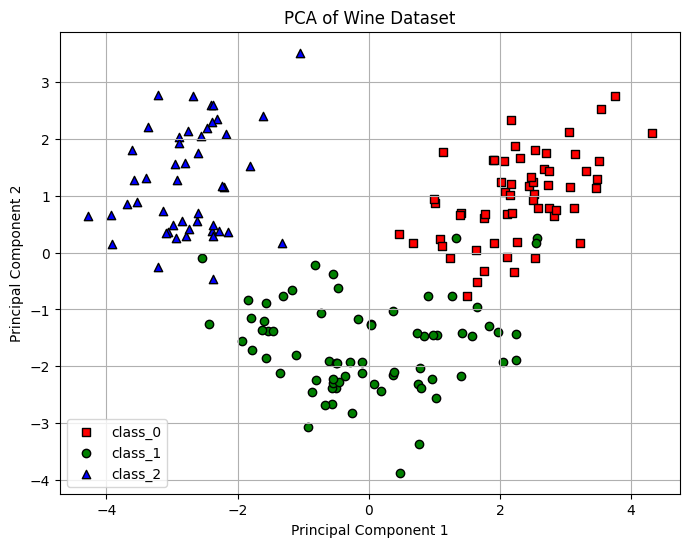

In [28]:
pca_df = pd.DataFrame(data=X_pca_wine, columns=["Principal Component 1", "Principal Component 2"])
pca_df["target"] = y
plt.figure(figsize=(8, 6))
colors = ["r", "g", "b"]
markers = ["s", "o", "^"]

for i, class_name in enumerate(wine.target_names):
    X_class = pca_df[pca_df["target"] == i]
    plt.scatter(
        X_class["Principal Component 1"],
        X_class["Principal Component 2"],
        c=colors[i],
        label=class_name,
        marker=markers[i],
        edgecolor="k",
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wine Dataset")
plt.legend()
plt.grid(True)
plt.show()

# 2. LDA

- LDA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [31]:
# LDA 라이브러리 불러오기
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [32]:
# LDA 적용 : n_components=5
lda = LinearDiscriminantAnalysis(n_components=5)

X_train_lda = lda.fit_transform(X_train, y_train)

X_test_lda = lda.transform(X_test)

In [33]:
# LDA 이후 랜덤포레스트 훈련
rf_clf_lda = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_lda.fit(X_train_lda, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [34]:
# 정확도 결과 (X_test도 LDA 적용해야합니다.)
y_pred_lda = rf_clf_lda.predict(X_test_lda)

# 정확도 출력
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"LDA 적용 후 Random Forest Test Accuracy: {accuracy_lda:.4f}")

LDA 적용 후 Random Forest Test Accuracy: 0.8301
